# **Welcome to 'Intracranial Hemorrhage Detection'**

Acute Intracranial Hemorrhage (ICH) is a critical medical emergency requiring rapid diagnostic intervention. Delayed diagnosis can lead to severe clinical complications, such as:

* Increased intracranial pressure
* Irreversible brain tissue damage
* Higher risk of patient mortality
* Delayed surgical or medical triage
* Human error during high-volume diagnostic workloads

To address this, we use Computer Vision to build a lightweight binary CNN framework that automates the detection of bleeding from head CT scans, augmenting standard radiological pipelines with automated statistical inference layers. You can download the dataset from this link ->
https://www.kaggle.com/datasets

# **Data exploration**

> THE FIRST STAGE


Data exploration uses visual exploration to explore dataset and understand the characteristics of the data. Now, let us visualize the data and see how the dataset is.

In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.layers import Dense
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image
import numpy as np
import scipy.stats as stats
import os


LET'S US PRINT SOME IMAGES

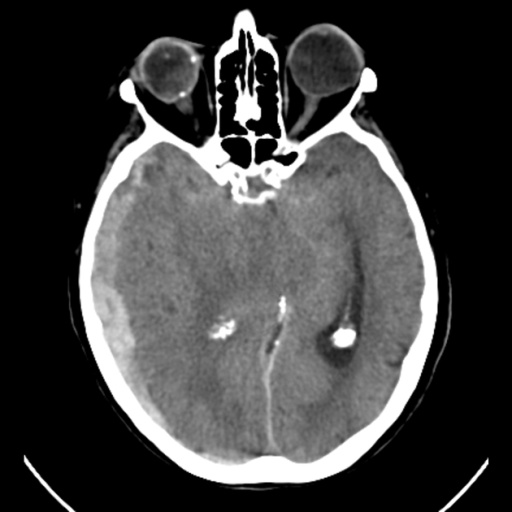

In [ ]:
# Replace this with the actual path to your image file in Google Drive
Image.open("C:\\report AIDA\\BRAIN_CT_DATASET\\test\\BRAIN_SAMPLE.jpg")

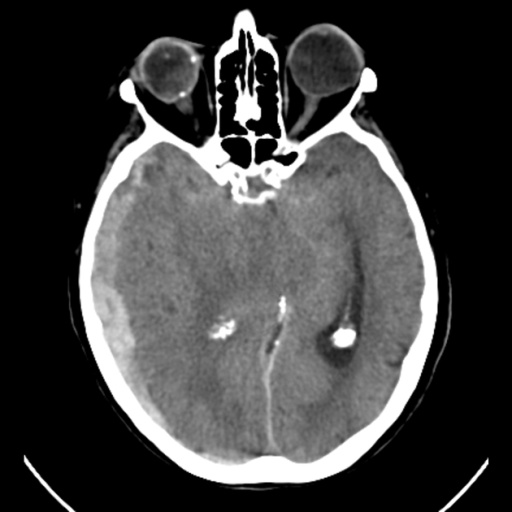

In [ ]:
# Replace this with the actual path to your image file in Google Drive
Image.open("C:\\report AIDA\\BRAIN_CT_DATASET\\test\\BRAIN_SAMPLE(2).jpg")

## ***MODEL PREPARATION***

In [ ]:
classifier = Sequential()
classifier.add(Conv2D(32, (3, 3), input_shape = (64, 64, 3), activation = 'relu'))
classifier.add(MaxPooling2D(pool_size = (2, 2)))

classifier.add(Conv2D(32, (3, 3), activation = 'relu'))
classifier.add(MaxPooling2D(pool_size = (2, 2)))
classifier.add(Flatten())

classifier.add(Dense(units = 128, activation = 'relu'))
classifier.add(Dense(units = 1, activation = 'sigmoid'))

classifier.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## ***MODEL TRAINING***
Now, the data generators are created and the model is trained.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

train_datagen = ImageDataGenerator(rescale = 1./255, validation_split = 0.2)
test_datagen = ImageDataGenerator(rescale = 1./255)

# Replace this with the actual path to your 'BRAIN_CT_DATASET' folder in Google Drive
dataset_path = "C:\\report AIDA\\BRAIN_CT_DATASET"

training_set = train_datagen.flow_from_directory(os.path.join(dataset_path, 'train'),
                                                 target_size = (64, 64),
                                                 batch_size = 32,
                                                 class_mode = 'binary',
                                                 subset='training')

validation_set = train_datagen.flow_from_directory(os.path.join(dataset_path, 'train'),
                                                   target_size = (64, 64),
                                                   batch_size = 32,
                                                   class_mode = 'binary',
                                                   subset='validation')

test_set = test_datagen.flow_from_directory(os.path.join(dataset_path, 'test'),
                                             target_size = (64, 64),
                                             batch_size = 32,
                                             class_mode = 'binary') # Removed subset='validation'

classifier.fit(training_set,
                         steps_per_epoch = training_set.samples // training_set.batch_size,
                         epochs = 4,
                         validation_data = validation_set,
                         validation_steps = validation_set.samples // validation_set.batch_size)

Found 2211 images belonging to 2 classes.
Found 551 images belonging to 2 classes.
Found 0 images belonging to 0 classes.
Epoch 1/4
69/69 ━━━━━━━━━━━━━━━━━━━━ 684s 10s/step - accuracy: 0.7439 - loss: 0.5379 - val_accuracy: 0.6710 - val_loss: 0.8198
Epoch 2/4
 1/69 ━━━━━━━━━━━━━━━━━━━━ 8s 124ms/step - accuracy: 0.7500 - loss: 0.4943

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.7500 - loss: 0.4943 - val_accuracy: 0.6618 - val_loss: 0.7895
Epoch 3/4
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 287ms/step - accuracy: 0.8990 - loss: 0.2623 - val_accuracy: 0.6360 - val_loss: 0.8479
Epoch 4/4
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.9375 - loss: 0.1439 - val_accuracy: 0.6213 - val_loss: 0.8688


## ***Model Testing***

To test how the model is, it is now applied on a sample image.

## Deploying to Streamlit

To deploy this model as a web application using Streamlit, we'll follow these steps:
1.  Install Streamlit.
2.  Save the trained Keras model.
3.  Create a Python script (`app.py`) for the Streamlit application.
4.  Run the Streamlit application.

In [ ]:
# Install Streamlit
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 59.1 MB/s eta 0:00:00


### Save the Trained Model

First, we need to save the trained `classifier` model so it can be loaded later by the Streamlit application.

In [ ]:
import os

# Define the path to save the model in your Google Drive
model_save_path = "C:\\report AIDA\\brain_hemorrhage_cnn_model.h5"

# Save the model
classifier.save(model_save_path)
print(f"Model saved to: {model_save_path}")

Model saved to: /content/drive/MyDrive/reportAIDA/brain_hemorrhage_cnn_model.h5


### Create Streamlit Application Script

Now, let's create the `app.py` script for your Streamlit application. This script will:
-   Load the saved Keras model.
-   Provide an interface to upload an image.
-   Preprocess the uploaded image.
-   Make a prediction using the loaded model.
-   Display the prediction result.

In [ ]:
%%writefile app.py
import streamlit as st
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
from PIL import Image
import os

# --- Streamlit App Configuration ---
st.set_page_config(page_title="Intracranial Hemorrhage Detection", layout="centered")

# --- Helper Functions ---
@st.cache_resource
def load_model(model_path):
    """Loads the pre-trained Keras model."""
    model = tf.keras.models.load_model(model_path)
    return model

def preprocess_image(uploaded_file, target_size=(64, 64)):
    """Preprocesses the uploaded image for model prediction."""
    img = Image.open(uploaded_file)
    img = img.resize(target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = img_array / 255.0  # Rescale to [0, 1] as per ImageDataGenerator
    return img_array

# --- Main Application Logic ---
def main():
    st.title("🧠 Intracranial Hemorrhage Detection")
    st.write("Upload a brain CT scan image to detect potential intracranial hemorrhage.")

    # Define the model path (adjust if you saved it elsewhere in Drive)
    model_path_in_colab = "C:\\report AIDA\\brain_hemorrhage_cnn_model.h5"

    # Since Streamlit runs independently, we need to ensure the model path is accessible.
    # For local deployment, you would place 'brain_hemorrhage_cnn_model.h5' in the same directory as 'app.py'
    # For this example, we assume app.py is run in an environment where /content/drive/MyDrive is mounted or the model is copied.
    # In a real-world deployment (e.g., on a cloud platform), you would upload the model alongside your app.py.
    # For this Colab simulation, we'll use the path where we just saved it.
    # In a local run, you'd move the .h5 file to the same folder as app.py or adjust the path.

    # Check if the model exists (this check is more for local execution sanity)
    if not os.path.exists(model_path_in_colab):
        st.error(f"Model file not found at {model_path_in_colab}. Please ensure the model is saved correctly and accessible.")
        st.stop()

    # Load the model
    model = load_model(model_path_in_colab)

    uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "jpeg", "png"])

    if uploaded_file is not None:
        # Display the uploaded image
        st.image(uploaded_file, caption='Uploaded CT Scan', use_column_width=True)
        st.write("")
        st.write("Classifying...")

        # Preprocess and predict
        processed_image = preprocess_image(uploaded_file)
        prediction = model.predict(processed_image)

        # Assuming binary classification with sigmoid activation
        if prediction[0][0] > 0.5:
            st.error(f"Prediction: **Hemorrhage Detected** (Confidence: {prediction[0][0]:.2f})")
        else:
            st.success(f"Prediction: **Normal Scan** (Confidence: {1 - prediction[0][0]:.2f})")

        st.write("---")
        st.write("**Note:** This is a demonstration for educational purposes. Always consult a medical professional for diagnosis.")


if __name__ == '__main__':
    main()

Writing app.py


### Run the Streamlit Application (Local Execution)

To run this Streamlit application, you would typically execute the following command in your terminal where `app.py` is located:

```bash
streamlit run app.py
```

**Note for Google Colab:** Directly running Streamlit apps within Colab that require a web interface can be tricky because Colab is a hosted environment. You would generally need to use tools like `ngrok` or `localtunnel` to expose the local Streamlit port to the internet.

However, for testing purposes, you can try to run it directly, though the output might not be a fully interactive web UI in the standard Colab output cell. The `!streamlit run app.py` command would start the server, but accessing the UI would require port forwarding.

For a full interactive experience, it's recommended to download `app.py` and `brain_hemorrhage_cnn_model.h5` and run `streamlit run app.py` on your local machine.

In [ ]:
# Replace this with the actual path to your image file in Google Drive
test_image_path = ("C:\\report AIDA\\BRAIN_CT_DATASET\\test\\BRAIN_SAMPLE.jpg")
test_image = image.load_img(test_image_path, target_size = (64, 64))
test_image = image.img_to_array(test_image)
test_image = np.expand_dims(test_image, axis = 0)
result = classifier.predict(test_image)

# 'training_set' needs to be defined from the previous cell for this to work
# Assuming training_set was successfully created, its class_indices can be accessed.
# If training_set creation fails, this line will also fail.
# Example: training_set.class_indices # Shows {'Normal': 0, 'Hemorrhage': 1}

# Manually define class_indices if training_set is not available yet for testing purposes
class_indices = {'Normal': 0, 'Hemorrhage': 1} # Adjust if your actual class indices are different

if result == 1:
    prediction = 'Hemorrhage Detected'
else:
    prediction = 'Normal Scan'

print("Prediction for medical scan layout:", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
Prediction for medical scan layout: Hemorrhage Detected


### Create `requirements.txt`

Streamlit Cloud needs a `requirements.txt` file in your repository to install all the dependencies for your application. Let's create one with the libraries currently used.

In [ ]:
%%writefile requirements.txt
streamlit
tensorflow
numpy
keras # Although part of tensorflow, sometimes good to explicitly include if older versions are needed.
pillow

Writing requirements.txt


### Deployment Steps for Streamlit and GitHub

Now that you have `app.py`, `brain_hemorrhage_cnn_model.h5`, and `requirements.txt`, here are the steps to deploy your application using Streamlit Cloud via GitHub:

1.  **Download the Files:**
    *   Download `app.py` from your Colab environment (it was created in cell `b0f77a3c`).
    *   Download `brain_hemorrhage_cnn_model.h5` from your Google Drive, as saved in cell `bd544531`.
    *   Download `requirements.txt` (just created in the previous cell).

2.  **Create a GitHub Repository:**
    *   Go to [GitHub](https://github.com/) and create a new public repository (e.g., `ich-detection-app`).

3.  **Upload Files to GitHub:**
    *   Upload `app.py`, `brain_hemorrhage_cnn_model.h5`, and `requirements.txt` to the root directory of your new GitHub repository. Ensure the model file is accessible at the path specified in `app.py` (which is `brain_hemorrhage_cnn_model.h5` if both are in the root).

4.  **Deploy on Streamlit Cloud:**
    *   Go to [Streamlit Cloud](https://share.streamlit.io/).
    *   Sign up or log in using your GitHub account.
    *   Click on the **'New app'** button.
    *   Select your GitHub repository from the dropdown list.
    *   Ensure the branch is `main` (or whichever branch you pushed to).
    *   Set the **Main file path** to `app.py`.
    *   Click **'Deploy!'**

Streamlit Cloud will now build your application, install the dependencies from `requirements.txt`, and deploy it. Once deployed, you'll get a URL to access your interactive web application.

After running the above cell, you should see a `Streamlit App URL:` printed. Click on that URL to access your interactive Streamlit application.

**Note:** If the cell keeps running indefinitely and you don't see the URL, ensure your `NGROK_AUTH_TOKEN` is correctly set and that `app.py` is in the current directory (`/content/`). You may need to refresh the page or restart the runtime if issues persist.

In [ ]:
!ls -l /content/app.py
# If this command shows 'No such file or directory', then app.py is missing.